In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "output/summary"
OUT_DIR = "output/analysis"
FIG_DIR = os.path.join(OUT_DIR, "figures")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

A_PATH = os.path.join(BASE_DIR, "pricing_A_base_summary.csv")
B_PATH = os.path.join(BASE_DIR, "pricing_B_base_summary.csv")
C_PATH = os.path.join(BASE_DIR, "pricing_C_base_summary.csv")

('output/summary/pricing_A_base_summary.csv',
 'output/summary/pricing_B_base_summary.csv',
 'output/summary/pricing_C_base_summary.csv')

In [3]:
A = pd.read_csv(A_PATH)
B = pd.read_csv(B_PATH)
C = pd.read_csv(C_PATH)

for name, df in [("A", A), ("B", B), ("C", C)]:
    print(name, df.shape)
    required = ["algo", "price_mean", "price_ci95_low", "price_ci95_high", "price_ci95_halfwidth",
                "duration_mean", "comp_time_mean", "time_path_gen_mean", "n_runs"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"WARNING: {name} missing columns:", missing)
    else:
        print(f"{name} OK")


A (12, 23)
A OK
B (3, 23)
B OK
C (12, 23)
C OK


In [5]:
def scenario_cols_present(df):
    # базовый набор из summarize_pricing.py (может расширяться)
    base = ["model", "payoff", "spot", "strike", "maturity",
            "volatility", "drift", "dividend", "nb_stocks", "nb_dates", "nb_paths"]
    return [c for c in base if c in df.columns]

def get_unique_scenarios(df):
    cols = scenario_cols_present(df)
    if not cols:
        return pd.DataFrame()
    return df[cols].drop_duplicates().reset_index(drop=True)

def pick_first_scenario(df):
    cols = scenario_cols_present(df)
    if not cols:
        return df.copy()
    uniq = get_unique_scenarios(df)
    if len(uniq) == 0:
        return df.copy()
    sc = uniq.iloc[0].to_dict()
    mask = np.ones(len(df), dtype=bool)
    for c, v in sc.items():
        mask &= (df[c] == v)
    return df.loc[mask].copy()

def with_ci_halfwidth(df):
    df = df.copy()
    # на всякий случай: если halfwidth не сохранён
    if "price_ci95_halfwidth" not in df.columns and "price_se" in df.columns:
        df["price_ci95_halfwidth"] = 1.96 * df["price_se"]
    return df

def save_table(df, out_name):
    out_path = os.path.join(OUT_DIR, out_name)
    df.to_csv(out_path, index=False)
    print("Saved:", out_path)
    return out_path


In [19]:
A1 = pick_first_scenario(A)
A1 = with_ci_halfwidth(A1)

A_table = A1[[
    *scenario_cols_present(A1),
    "algo", "n_runs",
    "price_mean", "price_ci95_low", "price_ci95_high", "price_ci95_halfwidth",
    "duration_mean", "time_path_gen_mean", "comp_time_mean"
]].sort_values("algo").reset_index(drop=True)

A_table


,model,payoff,spot,strike,maturity,volatility,drift,dividend,nb_stocks,nb_dates,nb_paths,algo,n_runs,price_mean,price_ci95_low,price_ci95_high,price_ci95_halfwidth,duration_mean,time_path_gen_mean,comp_time_mean
0,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,2000,LSM,20.0,6.040005,5.911526,6.168484,0.128479,0.028108,0.011267,0.016841
1,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,2000,NLSM,20.0,6.004540,5.928618,6.080462,0.075922,2.188066,0.012599,2.175466
2,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,2000,RLSM,20.0,5.720469,5.639408,5.801531,0.081061,0.218294,0.014301,0.203993


In [18]:
save_table(A_table, "A_base_table.csv")

Saved: output/analysis/A_base_table.csv


'output/analysis/A_base_table.csv'

Saved: output/analysis/figures/A_price_ci.png


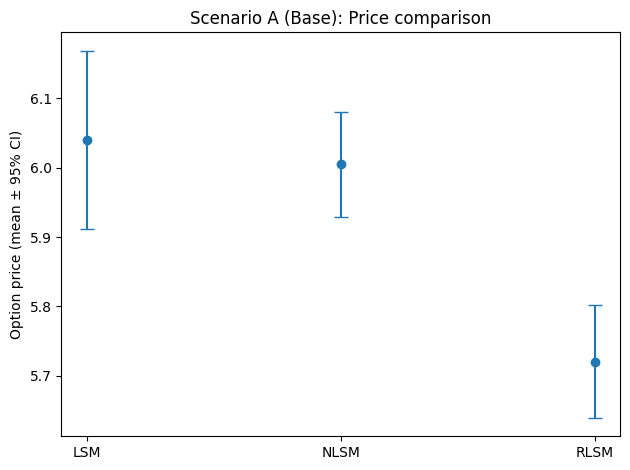

In [34]:
df = A_table.copy().sort_values("algo")
x = np.arange(len(df))
y = df["price_mean"].values
err = df["price_ci95_halfwidth"].values

plt.figure()
plt.errorbar(x, y, yerr=err, fmt='o', capsize=5)
plt.xticks(x, df["algo"].values, rotation=0)
plt.ylabel("Option price (mean ± 95% CI)")
plt.title("Scenario A (Base): Price comparison")
plt.tight_layout()

out = os.path.join(FIG_DIR, "A_price_ci.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


Saved: output/analysis/figures/A_runtime.png


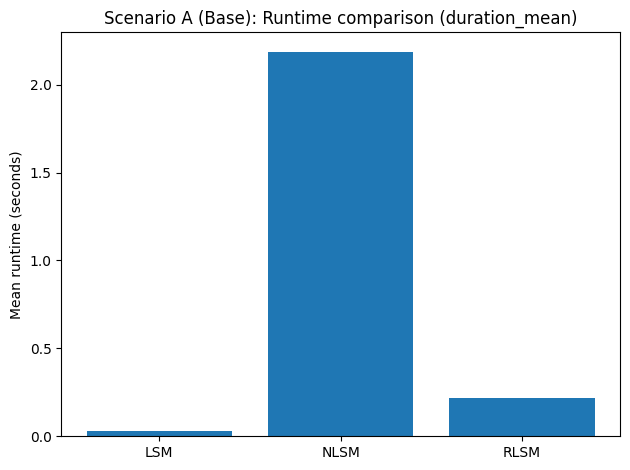

In [21]:
df = A_table.copy().sort_values("algo")
x = np.arange(len(df))

plt.figure()
plt.bar(x, df["duration_mean"].values)
plt.xticks(x, df["algo"].values, rotation=0)
plt.ylabel("Mean runtime (seconds)")
plt.title("Scenario A (Base): Runtime comparison (duration_mean)")
plt.tight_layout()

out = os.path.join(FIG_DIR, "A_runtime.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


In [22]:
B1 = B.copy()
B1 = with_ci_halfwidth(B1)

# таблица "как есть", сортируем для удобства
cols = scenario_cols_present(B1)
B_table = B1[[
    *cols,
    "algo", "n_runs",
    "price_mean", "price_ci95_halfwidth",
    "duration_mean", "time_path_gen_mean", "comp_time_mean"
]].sort_values([c for c in cols if c != "nb_paths"] + ["nb_paths", "algo"]).reset_index(drop=True)

B_table.head(20)


,model,payoff,spot,strike,maturity,volatility,drift,dividend,nb_stocks,nb_dates,nb_paths,algo,n_runs,price_mean,price_ci95_halfwidth,duration_mean,time_path_gen_mean,comp_time_mean
0,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,LSM,20.0,6.059239,0.033012,0.288797,0.126162,0.162635
1,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,NLSM,20.0,6.029611,0.029229,9.849935,0.100917,9.749018
2,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,RLSM,20.0,6.009412,0.037492,1.364395,0.139626,1.224769


In [31]:
save_table(B_table, "B_pathsweep_table.csv")

Saved: output/analysis/B_pathsweep_table.csv


'output/analysis/B_pathsweep_table.csv'

Saved: output/analysis/figures/B_price_vs_paths.png


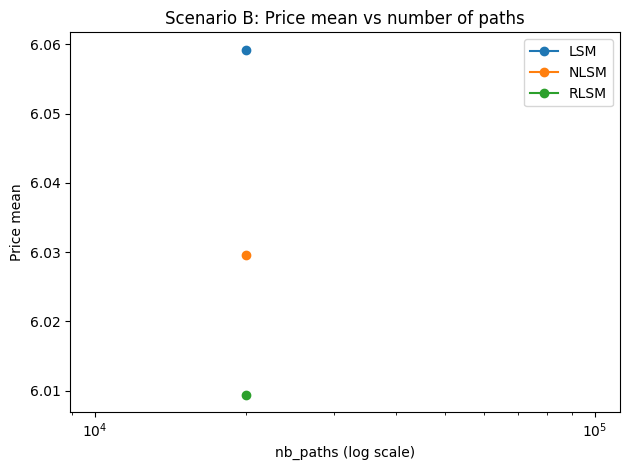

In [35]:
df = B_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_paths")
    plt.plot(g["nb_paths"], g["price_mean"], marker='o', label=algo)

plt.xscale("log")  # удобно, если paths растут экспоненциально
plt.xlabel("nb_paths (log scale)")
plt.ylabel("Price mean")
plt.title("Scenario B: Price mean vs number of paths")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "B_price_vs_paths.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


Saved: output/analysis/figures/B_ci_vs_paths.png


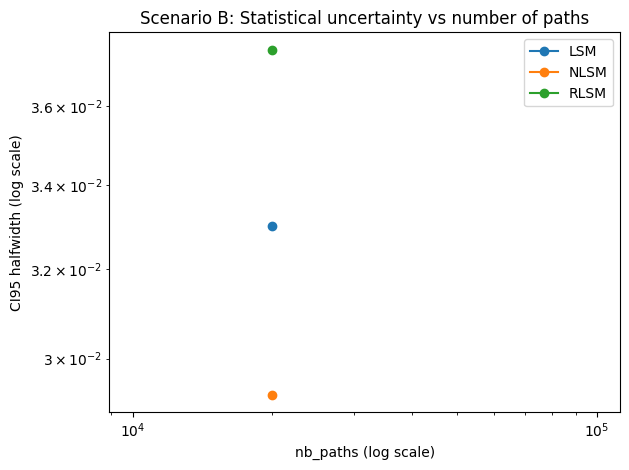

In [24]:
df = B_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_paths")
    plt.plot(g["nb_paths"], g["price_ci95_halfwidth"], marker='o', label=algo)

plt.xscale("log")
plt.yscale("log")  # CI часто падает примерно как 1/sqrt(M)
plt.xlabel("nb_paths (log scale)")
plt.ylabel("CI95 halfwidth (log scale)")
plt.title("Scenario B: Statistical uncertainty vs number of paths")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "B_ci_vs_paths.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


Saved: output/analysis/figures/B_runtime_vs_paths.png


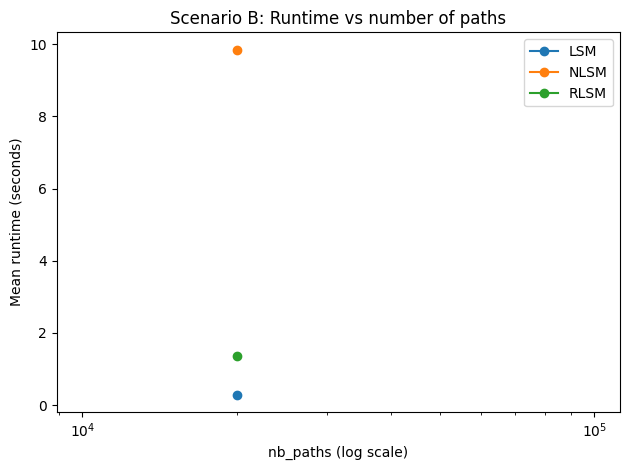

In [25]:
df = B_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_paths")
    plt.plot(g["nb_paths"], g["duration_mean"], marker='o', label=algo)

plt.xscale("log")
plt.xlabel("nb_paths (log scale)")
plt.ylabel("Mean runtime (seconds)")
plt.title("Scenario B: Runtime vs number of paths")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "B_runtime_vs_paths.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


In [26]:
C1 = C.copy()
C1 = with_ci_halfwidth(C1)

cols = scenario_cols_present(C1)
C_table = C1[[
    *cols,
    "algo", "n_runs",
    "price_mean", "price_ci95_halfwidth",
    "duration_mean", "time_path_gen_mean", "comp_time_mean"
]].sort_values([c for c in cols if c != "nb_dates"] + ["nb_dates", "algo"]).reset_index(drop=True)

C_table.head(20)


,model,payoff,spot,strike,maturity,volatility,drift,dividend,nb_stocks,nb_dates,nb_paths,algo,n_runs,price_mean,price_ci95_halfwidth,duration_mean,time_path_gen_mean,comp_time_mean
0,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,25,20000,LSM,20.0,6.035834,0.033708,0.165236,0.074675,0.090561
1,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,25,20000,NLSM,20.0,6.023763,0.033740,5.170423,0.065894,5.104529
2,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,25,20000,RLSM,20.0,6.017585,0.033651,0.668027,0.084676,0.583351
3,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,LSM,20.0,6.088311,0.024973,0.352521,0.138831,0.213689
4,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,NLSM,20.0,6.034098,0.032802,9.201802,0.098093,9.103709
5,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,50,20000,RLSM,20.0,6.010449,0.037072,1.288490,0.110867,1.177623
6,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,100,20000,LSM,20.0,6.071273,0.027402,0.676552,0.252553,0.423999
7,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,100,20000,NLSM,20.0,6.031275,0.034163,19.124940,0.222809,18.902132
8,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,100,20000,RLSM,20.0,6.022781,0.036582,2.179941,0.265207,1.914734
9,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,1,200,20000,LSM,20.0,6.061359,0.030880,1.385073,0.504596,0.880477


In [33]:
save_table(C_table, "C_datesweep_table.csv")


Saved: output/analysis/C_datesweep_table.csv


'output/analysis/C_datesweep_table.csv'

Saved: output/analysis/figures/C_price_vs_dates.png


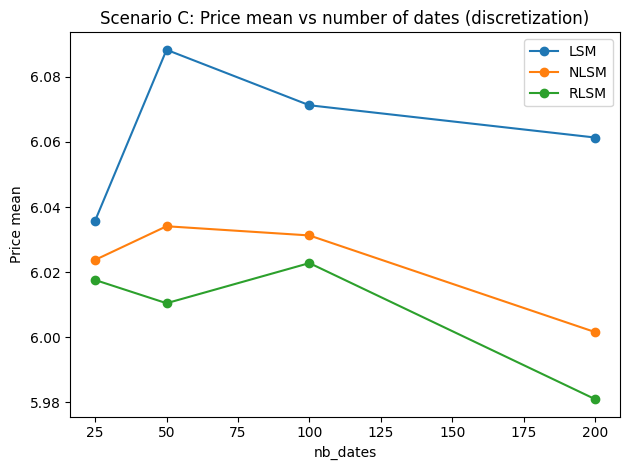

In [27]:
df = C_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_dates")
    plt.plot(g["nb_dates"], g["price_mean"], marker='o', label=algo)

plt.xlabel("nb_dates")
plt.ylabel("Price mean")
plt.title("Scenario C: Price mean vs number of dates (discretization)")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "C_price_vs_dates.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


Saved: output/analysis/figures/C_ci_vs_dates.png


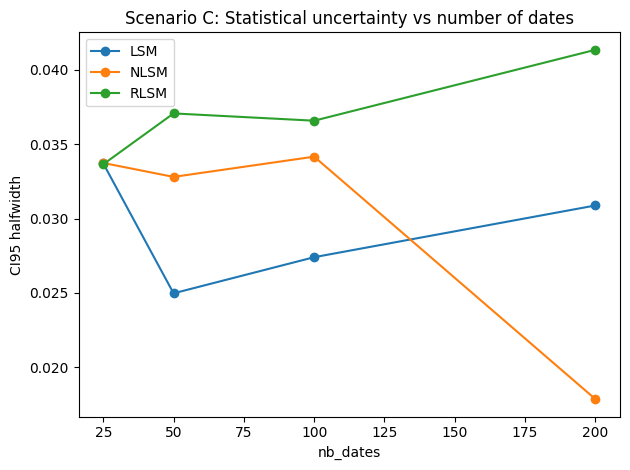

In [28]:
df = C_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_dates")
    plt.plot(g["nb_dates"], g["price_ci95_halfwidth"], marker='o', label=algo)

plt.xlabel("nb_dates")
plt.ylabel("CI95 halfwidth")
plt.title("Scenario C: Statistical uncertainty vs number of dates")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "C_ci_vs_dates.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


Saved: output/analysis/figures/C_runtime_vs_dates.png


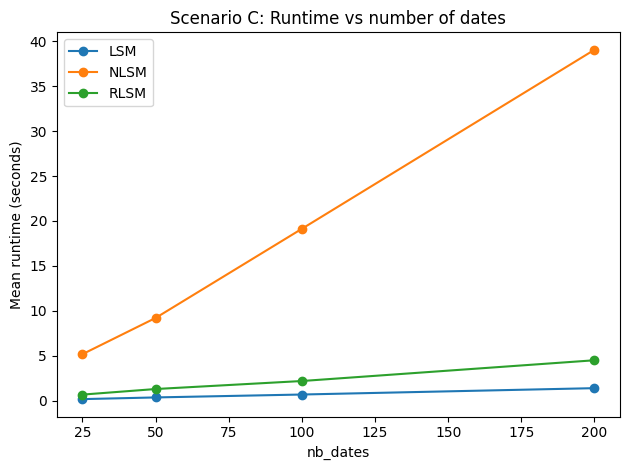

In [29]:
df = C_table.copy()

plt.figure()
for algo, g in df.groupby("algo"):
    g = g.sort_values("nb_dates")
    plt.plot(g["nb_dates"], g["duration_mean"], marker='o', label=algo)

plt.xlabel("nb_dates")
plt.ylabel("Mean runtime (seconds)")
plt.title("Scenario C: Runtime vs number of dates")
plt.legend()
plt.tight_layout()

out = os.path.join(FIG_DIR, "C_runtime_vs_dates.png")
plt.savefig(out, dpi=200)
print("Saved:", out)
plt.show()


In [30]:
def summarize_text_base(A_table):
    lines = []
    lines.append("Scenario A (Base): pricing comparison")
    for _, r in A_table.sort_values("algo").iterrows():
        lines.append(
            f"- {r['algo']}: price={r['price_mean']:.6f} "
            f"± {r['price_ci95_halfwidth']:.6f} (95% CI), "
            f"duration_mean={r['duration_mean']:.3f}s"
        )
    return "\n".join(lines)

print(summarize_text_base(A_table))


Scenario A (Base): pricing comparison
- LSM: price=6.040005 ± 0.128479 (95% CI), duration_mean=0.028s
- NLSM: price=6.004540 ± 0.075922 (95% CI), duration_mean=2.188s
- RLSM: price=5.720469 ± 0.081061 (95% CI), duration_mean=0.218s
